# Análise de Tempos no Fluxo de Atendimento de Pacientes com IAMCSST – Projeto SUPRA

O infarto agudo do miocárdio com supradesnivelamento do ST (IAMCSST) requer reperfusão rápida para reduzir mortalidade. O projeto SUPRA foi desenvolvido para otimizar o fluxo de atendimento e reduzir o tempo porta-balão (TPB).
Este estudo analisa os dados do fluxo assistencial para identificar gargalos e avaliar o desempenho do sistema.

O Fluxo segue as seguintes etapas:
- Admissão na Unidade de Origem (UPA/CAIS)
- Classificação de risco (Se dor no peito) >> Faz ECG
- ECG feito é enviado e laudado por telemedicina
- Identificado traçado de IAMCSST ('Infarto') é disparado o alerta para o SAMU e o Hospital de Alta Complexidade
- A Unidade de Origem solicita o transporte (SAMU)
- O transporte busca o paciente na Unidade de Origem e transporta até o Hospital
- O paciente é recebido no Pronto Socorro do Hospital e encaminhado para a Hemodinâmica para fazer o exame de Cateterismo cardíaco
- Durante cateterismo cardíaco caso identifique que o paciente tenha 'lesão grave/obstrução de artéria coronária' é feita a Angioplastia.

Observação: base anonimizada utilizada para fins de portfólio.

# 2. Descrição dos dados

Período: 2023–2025

Pacientes com suspeita de IAMCSST confirmados

Variáveis de tempo do fluxo assistencial

In [1]:
#Importar bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
#Carregar os dados

file_path = "../data/Base_Portfolio_1.xlsx"

df = pd.read_excel(file_path)
df.head()

,data_admissao,Paciente,unidade_origem,confirmado_IAM_com_supra?,horario_admissao_origem,tpe,tempo_unidade_origem,tempo_de_transporte,tpb_minutos_total,tpb_hospital,obito,sexo,idade
0,2023-08,P001,1,0,18:23:00,00:33:00,01:32:00,00:14:00,NaN,NaN,0.0,M,68.0
1,2023-08,P002,3,1,08:12:00,00:38:00,01:58:00,00:20:00,179.0,00:41:00,0.0,M,35.0
2,2023-08,P003,3,1,09:30:00,00:23:00,01:33:00,00:21:00,141.0,00:27:00,0.0,M,70.0
3,2023-08,P004,3,0,16:00:00,00:27:00,00:38:00,02:01:00,NaN,NaN,0.0,M,NaN
4,2023-08,P005,4,0,17:10:00,00:21:00,02:33:00,00:01:00,NaN,NaN,0.0,M,NaN


In [3]:
#Dimensões do DataFrame

df.shape

(724, 13)

In [4]:
#Tipos de dados e informações gerais

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   data_admissao              724 non-null    str    
 1   Paciente                   724 non-null    str    
 2   unidade_origem             724 non-null    int64  
 3   confirmado_IAM_com_supra?  724 non-null    int64  
 4   horario_admissao_origem    624 non-null    object 
 5   tpe                        609 non-null    object 
 6   tempo_unidade_origem       542 non-null    object 
 7   tempo_de_transporte        544 non-null    object 
 8   tpb_minutos_total          271 non-null    float64
 9   tpb_hospital               341 non-null    object 
 10  obito                      723 non-null    float64
 11  sexo                       724 non-null    str    
 12  idade                      581 non-null    float64
dtypes: float64(3), int64(2), object(5), str(3)
memory usage: 73.7

In [5]:
#Dados faltantes

df.isna().sum().sort_values(ascending=False)

tpb_minutos_total            453
tpb_hospital                 383
tempo_unidade_origem         182
tempo_de_transporte          180
idade                        143
tpe                          115
horario_admissao_origem      100
obito                          1
data_admissao                  0
confirmado_IAM_com_supra?      0
unidade_origem                 0
Paciente                       0
sexo                           0
dtype: int64

# Dicionário de Dados

## Principais variáveis

- `confirmado_IAM_com_supra?`: indicador de confirmação diagnóstica
- `tpe`: tempo porta-ECG
- `tempo_unidade_origem`: tempo total na unidade inicial
- `tempo_de_transporte`: tempo do transporte
- `tpb_minutos_total`: tempo porta-balão total
- `tpb_hospital`: tempo porta-balão no hospital
- `obito`: desfecho clínico

# 3. Preparação dos dados

In [6]:
#Converter a coluna "data_admissao" para o tipo datetime

df["data_admissao"] = pd.to_datetime(df["data_admissao"])

In [7]:
#colunas estão misturadas. Algumas células são do tipo datetime.timedelta, outras são do tipo datetime.time, outras já são float, outras são NaN. 
#Para o pandas, isso é um problema, pois ele não sabe como lidar com tipos mistos. 
# A solução é tratar cada tipo de dado de forma adequada, convertendo-os para um formato consistente, como minutos. 
# Para isso, vamos criar uma função que converta os valores para minutos, levando em consideração os diferentes tipos de dados presentes nas colunas.

from datetime import time
import pandas as pd

cols = [
    "tpe",
    "tempo_unidade_origem",
    "tempo_de_transporte",
    "tpb_hospital"
]

def tempo_para_minutos(x):

    if pd.isna(x):
        return None

    # caso seja datetime.time
    if isinstance(x, time):
        return x.hour * 60 + x.minute + x.second / 60

    # caso já seja número
    if isinstance(x, (int, float)):
        return x

    # caso seja string tipo 00:33:00
    try:
        td = pd.to_timedelta(x)
        return td.total_seconds() / 60
    except:
        return None


for col in cols:
    df[col] = df[col].apply(tempo_para_minutos)

In [8]:
#Converter as colunas para o tipo inteiro, arredondando os valores para o número inteiro mais próximo

df[cols] = df[cols].round().astype("Int64")

In [9]:
#Verificar as primeiras linhas do DataFrame para confirmar as alterações

df[cols].head()

,tpe,tempo_unidade_origem,tempo_de_transporte,tpb_hospital
0,33,92,14,<NA>
1,38,118,20,41
2,23,93,21,27
3,27,38,121,<NA>
4,21,153,1,<NA>


In [10]:
#Quantidade de IAMCSST confirmados vs não confirmados

df["confirmado_IAM_com_supra?"].value_counts()

confirmado_IAM_com_supra?
1    383
0    341
Name: count, dtype: int64

In [11]:
#Porcentagem de IAMCSST confirmados vs não confirmados

df["confirmado_IAM_com_supra?"].value_counts(normalize=True) * 100

confirmado_IAM_com_supra?
1    52.900552
0    47.099448
Name: proportion, dtype: float64

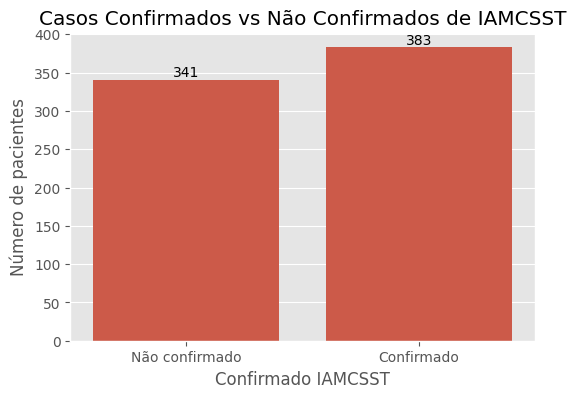

In [12]:
#Gráfico de barras para visualizar a quantidade de casos confirmados vs não confirmados de IAMCSST

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="confirmado_IAM_com_supra?"
)

plt.title("Casos Confirmados vs Não Confirmados de IAMCSST")
plt.xlabel("Confirmado IAMCSST")
plt.ylabel("Número de pacientes")
plt.xticks([0,1], ["Não confirmado", "Confirmado"])

# adiciona os números nas barras
for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Análise dos casos confirmados de IAMCSST

In [13]:
#Criar um novo DataFrame apenas com os casos confirmados de IAMCSST para análises futuras

df_iam = df[df["confirmado_IAM_com_supra?"] == 1].copy()

In [14]:
#Dimensões do novo DataFrame com casos confirmados de IAMCSST

df_iam.shape

(383, 13)

In [15]:
#Quantidade de IAMCSST confirmados vs não confirmados no novo DataFrame (deve ser apenas 1 valor, pois filtramos apenas os confirmados)

df_iam["confirmado_IAM_com_supra?"].value_counts()

confirmado_IAM_com_supra?
1    383
Name: count, dtype: int64

In [16]:
# Análise descritiva das variáveis de tempo para os casos confirmados de IAMCSST

variaveis_tempo = [
    "tpe",
    "tempo_unidade_origem",
    "tempo_de_transporte",
    "tpb_hospital",
    "tpb_minutos_total"
]

df_iam[variaveis_tempo].describe().T

,count,mean,std,min,25%,50%,75%,max
tpe,362.0,36.502762,83.631537,0.0,8.0,16.0,38.0,1387.0
tempo_unidade_origem,304.0,116.154605,139.704423,0.0,53.75,74.0,126.0,1257.0
tempo_de_transporte,297.0,23.548822,18.102705,0.0,15.0,20.0,27.0,217.0
tpb_hospital,334.0,50.796407,20.149453,5.0,37.0,48.0,61.75,164.0
tpb_minutos_total,271.0,140.262054,40.618728,50.0,113.0,133.0,163.0,301.0


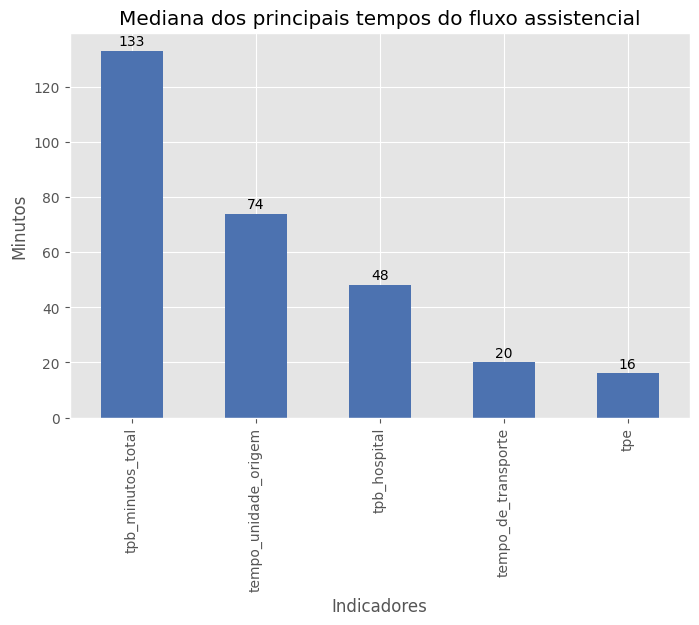

In [17]:
medianas = df_iam[variaveis_tempo].median().sort_values(ascending=False)

plt.figure(figsize=(8,5))

ax = medianas.plot(kind="bar")

plt.title("Mediana dos principais tempos do fluxo assistencial")
plt.ylabel("Minutos")
plt.xlabel("Indicadores")
plt.xticks(rotation=45)

# adicionar valores acima das barras
for i, v in enumerate(medianas):
    ax.text(i, v + 2, f"{v:.0f}", ha="center")
    ax = medianas.plot(kind="bar", color="#4C72B0")

plt.show()

# Percentual dentro das metas clínicas

## Metas de cada variável

- `tpe`: ≤10 min
- `tempo_unidade_origem`: ≤40 min
- `tempo_de_transporte`: ≤20 min
- `tpb_minutos_total`: ≤120 min
- `tpb_hospital`: ≤60min

In [18]:
#Criar os indicadores booleanos para cada meta de tempo, indicando se cada paciente atendeu ou não a cada meta, com base nos seguintes critérios:

df_iam["meta_tpe"] = df_iam["tpe"] <= 10
df_iam["meta_unidade_origem"] = df_iam["tempo_unidade_origem"] <= 40
df_iam["meta_transporte"] = df_iam["tempo_de_transporte"] <= 20
df_iam["meta_tpb_hospital"] = df_iam["tpb_hospital"] <= 60
df_iam["meta_tpb_total"] = df_iam["tpb_minutos_total"] <= 120

In [19]:
#Calcular a porcentagem de pacientes que atenderam a cada meta de tempo

metas = pd.Series({
    "TPE ≤ 10 min": df_iam["meta_tpe"].mean() * 100,
    "Unidade origem ≤ 40 min": df_iam["meta_unidade_origem"].mean() * 100,
    "Transporte ≤ 20 min": df_iam["meta_transporte"].mean() * 100,
    "TPB hospital ≤ 60 min": df_iam["meta_tpb_hospital"].mean() * 100,
    "TPB total ≤ 120 min": df_iam["meta_tpb_total"].mean() * 100
}).round(1)

metas

TPE ≤ 10 min               36.7
Unidade origem ≤ 40 min    15.1
Transporte ≤ 20 min        52.5
TPB hospital ≤ 60 min      73.7
TPB total ≤ 120 min        24.5
dtype: float64

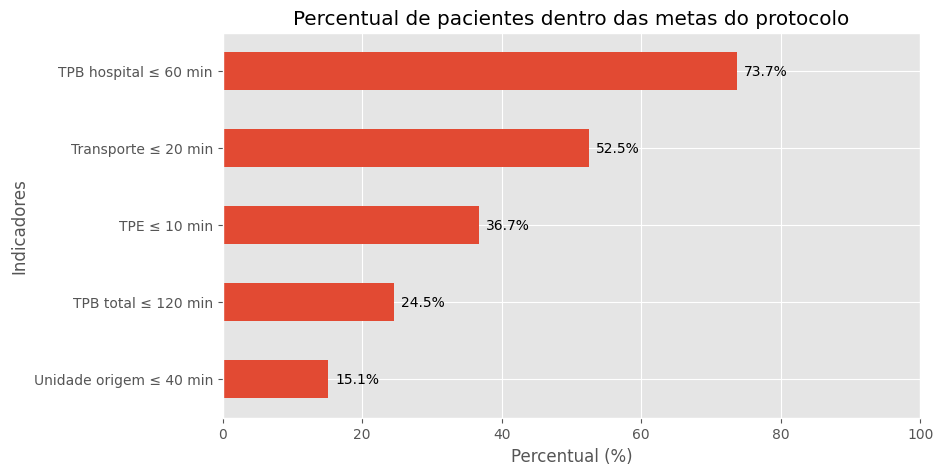

In [20]:
#Gráfico de barras horizontais para visualizar o percentual de pacientes dentro das metas do protocolo

plt.figure(figsize=(9,5))

ax = metas.sort_values().plot(kind="barh")

plt.title("Percentual de pacientes dentro das metas do protocolo")
plt.xlabel("Percentual (%)")
plt.ylabel("Indicadores")

for i, v in enumerate(metas.sort_values()):
    ax.text(v + 1, i, f"{v:.1f}%", va="center")

plt.xlim(0, 100)
plt.show()

# Interpretação de Indicadores

A análise dos indicadores mostra que o desempenho intra-hospitalar é relativamente adequado, com 73,7% dos pacientes atingindo TPB hospital ≤ 60 minutos, indicando eficiência na etapa interna após a chegada. No entanto, o transporte apresenta desempenho intermediário (52,5%), sugerindo variabilidade logística relacionada a fatores como distância, trânsito e disponibilidade de ambulâncias.

O principal gargalo do sistema está na fase pré-hospitalar, especialmente na unidade de origem. O TPE ≤ 10 minutos é baixo (36,7%), evidenciando atrasos na triagem, realização e interpretação do ECG, o que já compromete o início oportuno do atendimento. Esse problema se agrava ao observar que apenas 15,1% dos pacientes permanecem ≤ 40 minutos na unidade de origem, indicando demora na ativação do protocolo e na solicitação de transporte.

Como consequência, o desempenho global é insatisfatório: apenas 24,5% dos pacientes atingem TPB total ≤ 120 minutos. Isso demonstra que, apesar da boa performance hospitalar, o sistema como um todo falha principalmente nas etapas iniciais do cuidado, que concentram o maior impacto negativo no tempo total até a reperfusão.

# Decomposisão do Fluxo

In [21]:
#Calcular as médias dos tempos do fluxo assistencial para os casos confirmados de IAMCSST e ordenar do maior para o menor

medias_fluxo = df_iam[
    ["tempo_unidade_origem",
     "tempo_de_transporte",
     "tpb_hospital"]
].mean().sort_values(ascending=False)

medias_fluxo

tempo_unidade_origem    116.154605
tpb_hospital             50.796407
tempo_de_transporte      23.548822
dtype: Float64

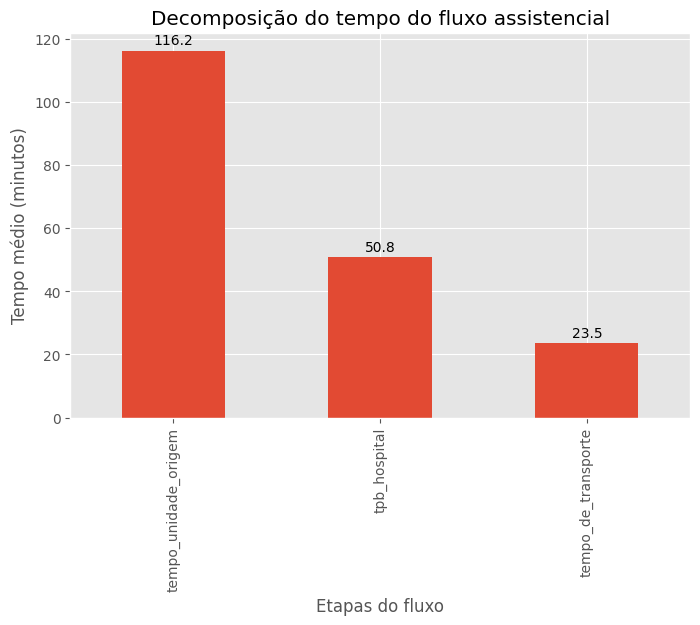

In [22]:
#Gráfico de barras para visualizar as médias dos tempos do fluxo assistencial para os casos confirmados de IAMCSST

plt.figure(figsize=(8,5))

ax = medias_fluxo.plot(kind="bar")

plt.title("Decomposição do tempo do fluxo assistencial")
plt.ylabel("Tempo médio (minutos)")
plt.xlabel("Etapas do fluxo")

for i, v in enumerate(medias_fluxo):
    ax.text(i, v + 2, f"{v:.1f}", ha="center")

plt.show()

A decomposição do tempo do fluxo assistencial demonstra que o maior componente do atraso ocorre na permanência do paciente na unidade de origem antes da transferência para o hospital de referência. Apesar do bom desempenho do tempo porta-balão hospitalar, atrasos iniciais no processo reduzem significativamente a probabilidade de atingir a meta de reperfusão dentro de 120 minutos.

# Evolução temporal do Projeto Supra

- O tempo porta-balão melhorou?
- O percentual dentro da meta aumentou?
- O Fluxo/Projeto está amadurecendo?

In [23]:
#Criar uma nova coluna "ano" extraindo o ano da coluna "data_admissao" para analisar a evolução dos casos confirmados de IAMCSST ao longo dos anos

df_iam["ano"] = pd.to_datetime(df_iam["data_admissao"]).dt.year
df_iam["mes"] = pd.to_datetime(df_iam["data_admissao"]).dt.to_period("M")

In [24]:
#Calcular a mediana do tempo total do paciente (tpb_minutos_total) por ano (2023-2025) para os casos confirmados de IAMCSST

tpb_por_ano = (
    df_iam[df_iam["ano"].between(2023, 2025)]
    .groupby("ano")["tpb_minutos_total"]
    .median()
)

tpb_por_ano

ano
2023    137.0
2024    132.5
2025    130.0
Name: tpb_minutos_total, dtype: float64

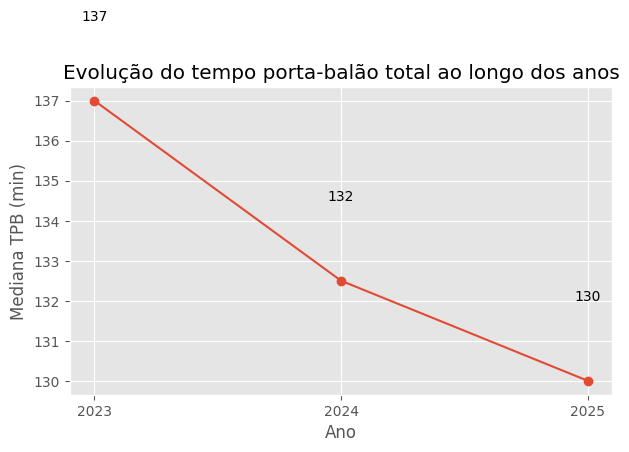

In [25]:
#Gráfico de linha para visualizar a evolução do tempo porta-balão total ao longo dos anos para os casos confirmados de IAMCSST

plt.figure(figsize=(7,4))

ax = tpb_por_ano.plot(marker="o")

plt.title("Evolução do tempo porta-balão total ao longo dos anos")
plt.ylabel("Mediana TPB (min)")
plt.xlabel("Ano")
plt.xticks([2023, 2024, 2025])

for i, v in enumerate(tpb_por_ano):
    ax.text(tpb_por_ano.index[i], v+2, f"{v:.0f}", ha="center")

plt.show()

In [26]:
#Calcular a porcentagem de pacientes que atenderam à meta do tempo porta-balão total (tpb_minutos_total ≤ 120) por ano para os casos confirmados de IAMCSST

meta_por_ano = (
    df_iam[df_iam["ano"].between(2023, 2025)]
    .groupby("ano")["tpb_minutos_total"]
    .apply(lambda x: (x <= 120).mean() * 100)
    .round(1)
)

meta_por_ano

ano
2023    34.4
2024    20.9
2025    27.4
Name: tpb_minutos_total, dtype: float64

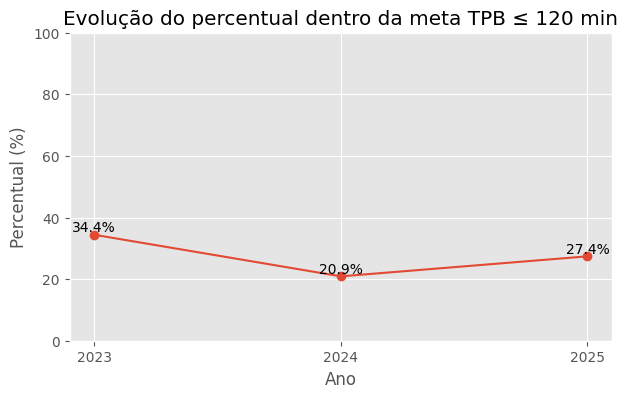

In [27]:
#Gráfico de linha para visualizar a evolução do percentual de pacientes dentro da meta do tempo porta-balão total ao longo dos anos para os casos confirmados de IAMCSST

plt.figure(figsize=(7,4))

ax = meta_por_ano.plot(marker="o")

plt.title("Evolução do percentual dentro da meta TPB ≤ 120 min")
plt.ylabel("Percentual (%)")
plt.xlabel("Ano")
plt.xticks([2023, 2024, 2025])

for i, v in enumerate(meta_por_ano):
    ax.text(meta_por_ano.index[i], v + 1, f"{v:.1f}%", ha="center")

plt.ylim(0, 100)

plt.show()

### A análise temporal do percentual de pacientes que atingiram a meta de TPB ≤ 120 minutos demonstra variação ao longo dos anos analisados. 

- Em 2023, aproximadamente 34,4% dos pacientes estavam dentro da meta. 
- Em 2024 observou-se uma queda para 20,9%, seguida de recuperação parcial em 2025 (27,4%). 

Esses resultados sugerem que, apesar de melhorias pontuais, o sistema ainda enfrenta desafios estruturais para garantir reperfusão dentro do tempo recomendado para a maioria dos pacientes.

<Figure size 700x400 with 0 Axes>

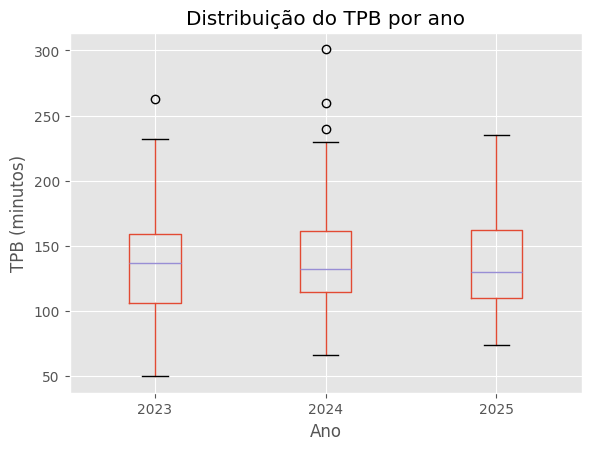

In [28]:
#Gráfico de boxplot para visualizar a distribuição do tempo porta-balão total por ano para os casos confirmados de IAMCSST

plt.figure(figsize=(7,4))

df_iam[df_iam["ano"].between(2023,2025)].boxplot(
    column="tpb_minutos_total",
    by="ano"
)

plt.title("Distribuição do TPB por ano")
plt.suptitle("")
plt.ylabel("TPB (minutos)")
plt.xlabel("Ano")

plt.show()

O TPB apresentou distribuição semelhante entre os anos analisados, com medianas próximas e presença de alguns outliers. Isso sugere estabilidade do fluxo assistencial ao longo do período, apesar de ocorrências pontuais de atraso.
A análise do TPB é relevante pois esse indicador está diretamente associado ao prognóstico de pacientes com IAM com supradesnivelamento do ST, sendo recomendado que o tempo seja mantido abaixo de 120 minutos.

# Modelo Preditivo
Pacientes vindos de determinadas unidades têm maior probabilidade de TPB > 120 min?
Regressão logística

In [29]:
#Criar um novo indicador binário "atraso_tpb" que indica se o tempo porta-balão total (tpb_minutos_total) foi superior a 120 minutos (1) ou não (0) para os casos confirmados de IAMCSST

df_iam["atraso_tpb"] = (df_iam["tpb_minutos_total"] > 120).astype(int)

In [30]:
#Calcular a quantidade de casos confirmados de IAMCSST por unidade de origem para os casos com atraso no tempo porta-balão total (atraso_tpb = 1)

df_iam["unidade_origem"].value_counts()

unidade_origem
4    113
5     82
3     72
2     58
1     36
6     22
Name: count, dtype: int64

In [31]:
#Criar um novo DataFrame apenas com as colunas "unidade_origem" e "atraso_tpb" para os casos confirmados de IAMCSST, removendo as linhas com valores faltantes

df_modelo_unidade = df_iam[
    ["unidade_origem", "atraso_tpb"]
].dropna()

In [32]:
#Criar variáveis dummy para a coluna "unidade_origem", removendo a primeira categoria para evitar multicolinearidade

df_modelo_unidade = pd.get_dummies(
    df_modelo_unidade,
    columns=["unidade_origem"],
    drop_first=True
)

In [33]:
#Separar as variáveis independentes (X) e a variável dependente (y) para o modelo de regressão logística

X = df_modelo_unidade.drop("atraso_tpb", axis=1)
y = df_modelo_unidade["atraso_tpb"]

In [34]:
#Ajustar um modelo de regressão logística para identificar se a unidade de origem está associada ao atraso no tempo porta-balão total (atraso_tpb) para os casos confirmados de IAMCSST

from sklearn.linear_model import LogisticRegression

modelo_unidade = LogisticRegression(max_iter=1000)
modelo_unidade.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [35]:
#Criar um DataFrame com os coeficientes do modelo de regressão logística para cada unidade de origem, ordenando do maior para o menor

coef_unidades = pd.Series(
    modelo_unidade.coef_[0],
    index=X.columns
).sort_values(ascending=False)

coef_unidades

unidade_origem_3    0.299269
unidade_origem_4    0.233130
unidade_origem_5    0.200843
unidade_origem_2   -0.083545
unidade_origem_6   -0.971595
dtype: float64

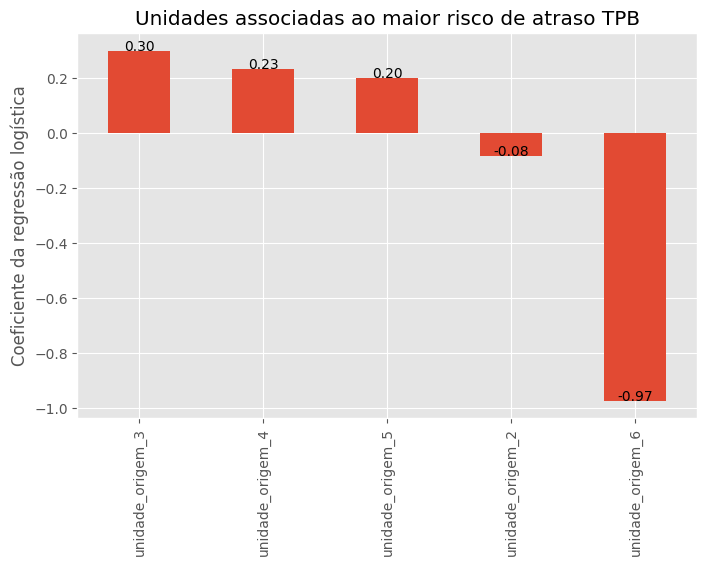

In [36]:
#Gráfico de barras para visualizar os coeficientes do modelo de regressão logística para cada unidade de origem, ordenados do maior para o menor, indicando quais unidades estão mais associadas ao atraso no tempo porta-balão total para os casos confirmados de IAMCSST

plt.figure(figsize=(8,5))

ax = coef_unidades.head(10).plot(kind="bar")

plt.title("Unidades associadas ao maior risco de atraso TPB")
plt.ylabel("Coeficiente da regressão logística")

for i, v in enumerate(coef_unidades.head(10)):
    ax.text(i, v, f"{v:.2f}", ha="center")

plt.show()

Leitura dos coeficientes

- coeficiente positivo → aumenta o risco de atraso
- coeficiente negativo → reduz o risco


Observou-se heterogeneidade significativa entre as unidades de origem em relação ao risco de atraso no tempo porta-balão. Algumas unidades apresentaram associação positiva com atraso, enquanto outras demonstraram desempenho superior, sugerindo maior eficiência no fluxo assistencial.

Os resultados indicam que intervenções direcionadas às unidades com maior risco de atraso podem gerar impacto relevante na melhoria do desempenho global do sistema, especialmente no que se refere ao tempo porta-balão.

Obs.: *Os coeficientes representam associação estatística e não necessariamente causalidade, podendo refletir diferenças estruturais entre unidades, como tempo de diagnóstico, logística de transporte ou disponibilidade de recursos.*

*A variação entre unidades sugere que o atraso no TPB não é uniforme no sistema, indicando a presença de gargalos localizados e oportunidades específicas de intervenção.*

# Ranking por unidades

OBS.: *O modelo preditivo identifica associação estatística, enquanto o ranking evidencia o impacto prático no desempenho.*

In [37]:
#Criar um ranking das unidades de origem com base na média do tempo porta-balão total (tpb_minutos_total) e na taxa de pacientes dentro da meta do tempo porta-balão total (1 - atraso_tpb) para os casos confirmados de IAMCSST, ordenando do pior para o melhor desempenho

ranking = (
    df_iam.groupby("unidade_origem")
    .agg(
        tpb_medio=("tpb_minutos_total", "mean"),
        taxa_meta=("atraso_tpb", lambda x: 1 - x.mean())
    )
    .sort_values(by="tpb_medio", ascending=False)
)

ranking

,tpb_medio,taxa_meta
unidade_origem,,
3,151.024333,0.486111
1,150.638889,0.555556
5,144.971914,0.512195
4,138.711961,0.504425
2,129.999242,0.586207
6,107.535714,0.818182


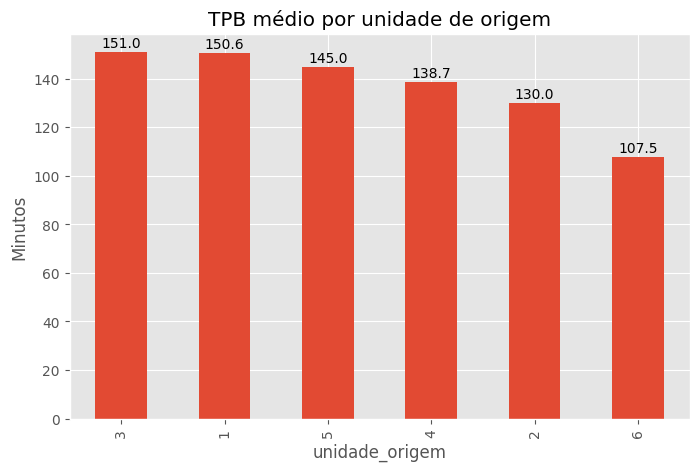

In [38]:
#Gráfico de barras para visualizar o ranking das unidades de origem com base na média do tempo porta-balão total para os casos confirmados de IAMCSST, ordenando do pior para o melhor desempenho

plt.figure(figsize=(8,5))

ax = ranking["tpb_medio"].plot(kind="bar")

plt.title("TPB médio por unidade de origem")
plt.ylabel("Minutos")

for i, v in enumerate(ranking["tpb_medio"]):
    ax.text(i, v + 2, f"{v:.1f}", ha="center")

plt.show()

# Conclusão do Projeto

## Síntese dos achados

A análise dos casos confirmados de IAMCSST evidenciou heterogeneidade relevante no desempenho do fluxo assistencial, especialmente no que se refere ao tempo porta-balão (TPB).

Observou-se que, apesar de parte dos pacientes atingir as metas estabelecidas, uma proporção significativa ainda apresenta atraso no tratamento, indicando oportunidades de melhoria no sistema.

## Principais determinantes do tempo porta-balão

A decomposição do fluxo assistencial demonstrou que o tempo total é fortemente influenciado pelas etapas pré-hospitalares, com destaque para:
- Tempo de permanência na unidade de origem
- Tempo de transporte inter-hospitalar

Esses achados sugerem que intervenções focadas nessas etapas podem gerar maior impacto na redução do TPB.

## Variabilidade entre unidades de origem

A análise por unidade revelou diferenças importantes no desempenho:
- Unidades como 3 e 1 apresentaram os maiores tempos porta-balão médios (~151 e ~150 minutos), associadas também a menor taxa de cumprimento da meta.
- Em contraste, a unidade 6 apresentou melhor desempenho, com TPB médio de aproximadamente 107 minutos e maior proporção de casos dentro da meta.

A regressão logística reforçou esses achados, demonstrando associação positiva entre determinadas unidades e maior risco de atraso no TPB.

## Implicações para a prática

Os resultados indicam que o atraso no TPB não ocorre de forma uniforme no sistema, estando concentrado em unidades específicas e etapas críticas do fluxo.
Dessa forma, estratégias direcionadas podem incluir:
- Otimização do tempo de diagnóstico na unidade de origem
- Padronização de protocolos de transferência
- Melhoria na logística de transporte
- Benchmarking com unidades de melhor desempenho

## Considerações metodológicas

Os modelos utilizados permitem identificar associações entre variáveis e o atraso no TPB, porém não estabelecem relações causais. As diferenças observadas podem refletir características estruturais das unidades, como disponibilidade de recursos, organização do fluxo assistencial ou perfil dos pacientes atendidos.

## Conclusão final

O projeto demonstra que a aplicação de técnicas de análise de dados e modelagem estatística pode contribuir significativamente para a identificação de gargalos no atendimento ao IAMCSST.

A abordagem utilizada permite não apenas descrever o desempenho do sistema, mas também direcionar intervenções estratégicas com potencial impacto clínico relevante, especialmente na redução do tempo porta-balão e, consequentemente, na melhoria dos desfechos dos pacientes.

Este tipo de análise pode ser incorporado em dashboards operacionais para monitoramento contínuo do desempenho do fluxo de IAMCSST.